In [1]:
import torch
import torch.nn as nn
torch.manual_seed(123)

In [6]:
GPT_2_config={
  "vocab":50257,
  "context_len":1024,
  "emb_dim":768,
  "n_head":12,
  "n_layer":12,
  "dropout":0.1,
  "qkv_bias":False  
}

## Gelu activation function
![Alt text for screen readers](./IMG/gelu.png)

In [2]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
        
    def forward(self, x):
        return 0.5*x*(1+torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi))*(x+0.044715*torch.pow(x,3))))

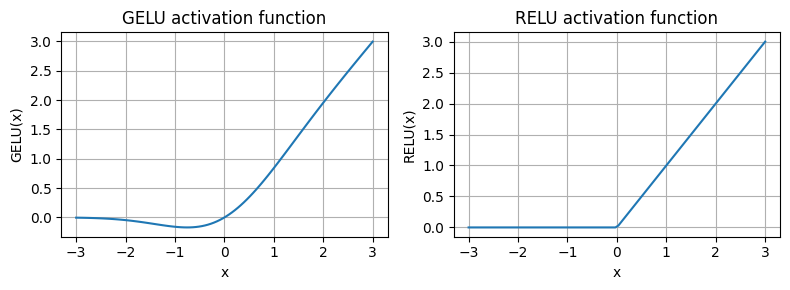

In [3]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8,3))

for i, (y,label) in enumerate(zip([y_gelu, y_relu], ["GELU", "RELU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x,y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
    
plt.tight_layout()
plt.show()

## Feed Forward Newtwork
![Alt text for screen readers](./IMG/feed_forward.png)

In [15]:
class FeedForward(nn.Module):
  def __init__(self,GPT_2_config):
    super().__init__()
    self.layer=nn.Sequential(
      nn.Linear(GPT_2_config["emb_dim"],4 * GPT_2_config["emb_dim"]), #expansion
      GELU()  ,               #activation
      nn.Linear(4 * GPT_2_config["emb_dim"], GPT_2_config["emb_dim"]) #contraction
    )
  def forward(self,x):
    return self.layer(x)  

## Test

In [18]:
GPT_2_config["emb_dim"]

768

In [ ]:
ffn=FeedForward(GPT_2_config)
x=torch.rand(2,3,GPT_2_config["emb_dim"]) #2-batch,3 token of 768 dim
out=ffn.forward(x)
print(out.shape)
out

torch.Size([2, 3, 768])


tensor([[[-0.1082,  0.0438,  0.0134,  ..., -0.0578, -0.0220, -0.1047],
         [-0.2544,  0.0160, -0.0704,  ...,  0.0933, -0.0682, -0.1529],
         [-0.2312, -0.0076,  0.0431,  ...,  0.0140, -0.0707, -0.1405]],

        [[-0.1217, -0.0028,  0.0048,  ...,  0.0395, -0.0595, -0.0828],
         [-0.0989, -0.0008, -0.0100,  ...,  0.0728, -0.1172, -0.1226],
         [-0.2537,  0.0376, -0.0267,  ...,  0.0042, -0.1076, -0.1280]]],
       grad_fn=<ViewBackward0>)